# <center> Practice. Statistical Tests in the Context of EDA

## Problem Statement

An HR agency is studying trends in the IT labor market. The company wants to conduct a study based on salary data in the Data Science field for 2020–2022 and draw some conclusions.

The HR agency wants to answer the following key questions regarding salaries for Data Scientists:

- Is there an annual salary increase for Data Scientists?
- How do salaries for Data Scientists and Data Engineers compare in 2022?
- How do salaries for Data Scientists compare in companies of different sizes?
- Is there a correlation between the presence of Data Scientists and Data Engineers and company size?

Each question must be answered with a significance level of 0.05.

To answer these questions, we'll use salary data, including employee and employer characteristics.

The data contains the following columns:
* *work_year* — Year in which the salary was paid.
* *experience_level* — Year of experience in this role, with the following possible values:
    * EN — Entry-level/Junior;
    * MI — Mid-level/Intermediate;
    * SE — Senior-level/Expert;
    * EX — Executive-level/Director.
* *employment_type* — Employment type for this role:
    * PT — Part-time;
    * FT — Full-time;
    * CT — Contract;
    * FL — Freelance.
* *job_title* — Role in which the applicant worked during the year.
* *salary* — Total gross salary paid.
* *salary_currency* — The currency of the salary paid, expressed as an ISO 4217 currency code.
* *salary_in_usd* — Salary in US dollars (the exchange rate divided by the average US dollar exchange rate for the corresponding year, as reported by fxdata.foorilla.com).
* *employee_residence* — The employee's primary country of residence during the work year, expressed as an ISO 3166 country code.
* *remote_ratio* — The total amount of work performed remotely. Possible values:
    * 0 — no remote work (less than 20%);
    * 50 — partially remote work;
    * 100 — fully remote work (more than 80%).
* *company_location* — Country of the employer's headquarters or contracted branch office, expressed as an ISO 3166 country code.
* *company_size* — Average number of people employed by the company during the year:
    * S — fewer than 50 employees (small company);
    * M — 50 to 250 employees (medium company);
    * L — more than 250 employees (large company).

Dataset source: ["Data Science Job Salaries" (kaggle.com)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

## Loading data

In [5]:
# Load the necessary libraries
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

# Customize the graphs visually
sns.set_theme("notebook")
sns.set_palette("Set2")

In [6]:
# load the dataset
data = pd.read_csv('data/ds_salaries.csv')
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [7]:
# set the significance level
alpha = 0.05

print("Significance level alpha = {:.2f}".format(alpha))

Significance level alpha = 0.05


## Descriptive data analysis

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


The dataset contains 607 records (without missing values).

Let's check the data for complete duplicates:

In [9]:
print('Number of duplicates: {}'.format(data[data.duplicated()].shape[0]))

# Removing duplicates:
data = data.drop_duplicates()
print('Table size after removing duplicates: {}'.format(data.shape))

Number of duplicates: 0
Table size after removing duplicates: (607, 12)


### Distribution of salary among Data Scientists

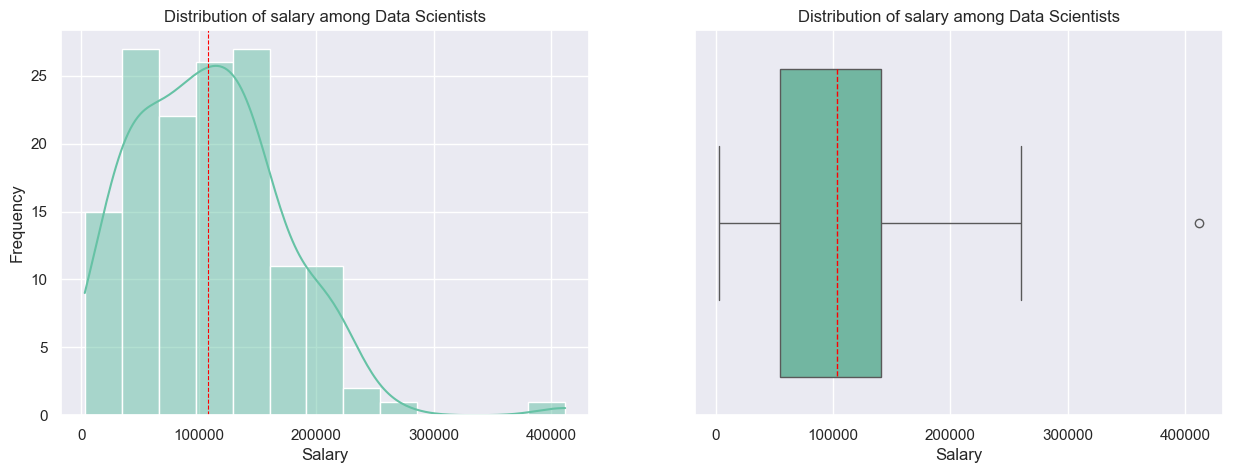

In [21]:
mask = data['job_title'] == 'Data Scientist'
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data[mask]['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='Salary', ylabel='Frequency')
axes[0].set_title('Distribution of salary among Data Scientists')
axes[0].axvline(data[mask]['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data[mask]['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Salary')
axes[1].set_title('Distribution of salary among Data Scientists')

plt.show()

In [22]:
data_agg = data[mask]['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['DS Salary']
data_agg

,DS Salary
count,143.00
mean,108187.83
std,64112.84
min,2859.00
25%,54724.00
50%,103691.00
75%,140850.00
max,412000.00


The distribution of wages is different from normal, there are outliers.

### Salaries depending on the year

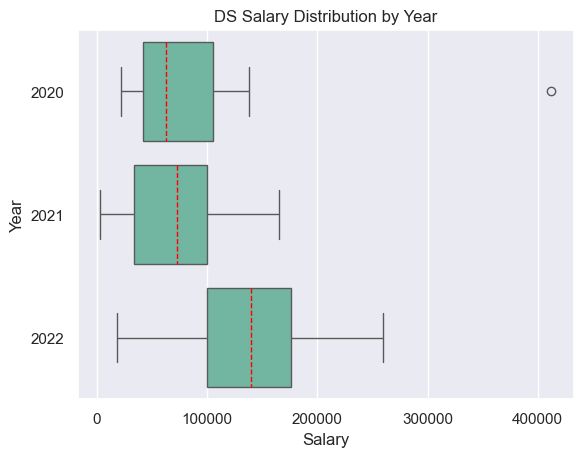

In [23]:
ax = sns.boxplot(data[mask], x='salary_in_usd', y='work_year', orient='h', medianprops={"color": "red", "linestyle": '--'})
ax.set(xlabel='Salary', ylabel='Year')
plt.title('DS Salary Distribution by Year')
plt.show()

In [24]:
data_agg = data[mask].groupby('work_year')['salary_in_usd'].describe().round(2)
print('DS Salaries by year')
data_agg

DS Salaries by year


,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,21.0,85970.52,81436.65,21669.0,42197.0,62726.0,105000.0,412000.0
2021,45.0,70671.73,45422.97,2859.0,33808.0,73000.0,100000.0,165000.0
2022,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


First, data scientists' salaries have increased annually. To determine whether these differences are statistically significant, we'll conduct statistical testing in the next section.

### Data Scientist vs. Data Engineer Salary Ratio in 2022.

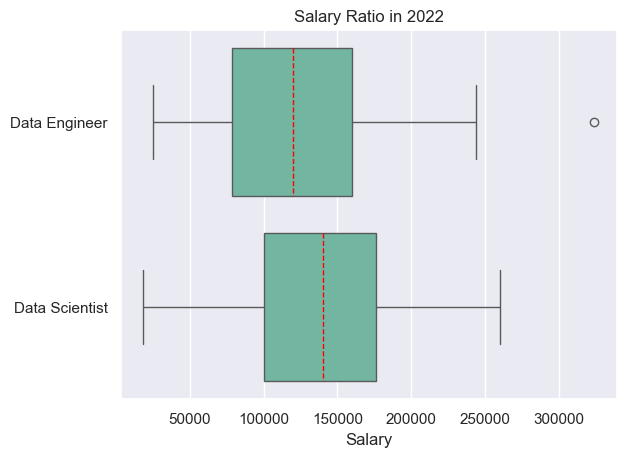

In [ ]:
ds = data['job_title'] == 'Data Scientist'
de = data['job_title'] == 'Data Engineer'
year = data['work_year'] == 2022

ax = sns.boxplot(
    data[(ds|de) & year],
    x='salary_in_usd',
    y='job_title',
    orient='h',
    medianprops={"color": "red", "linestyle": '--'}
)
ax.set(xlabel='Salary', ylabel=None)
plt.title('Salary Ratio in 2022')
plt.show()

In [29]:
data_agg = data[(ds|de) & year].groupby('job_title')['salary_in_usd'].describe().round(2)
print('Salary depending on position')
data_agg

Salary depending on position


,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
Data Engineer,89.0,126375.70,55954.40,25000.0,78526.0,120000.0,160000.0,324000.0
Data Scientist,77.0,136172.09,54563.08,18442.0,100000.0,140000.0,176000.0,260000.0


The salary distributions for Data Scientists and Data Engineers differ in 2022. To determine whether these differences are statistically significant, we will conduct statistical tests in the next section.

### Data Scientist Salaries by Company Size

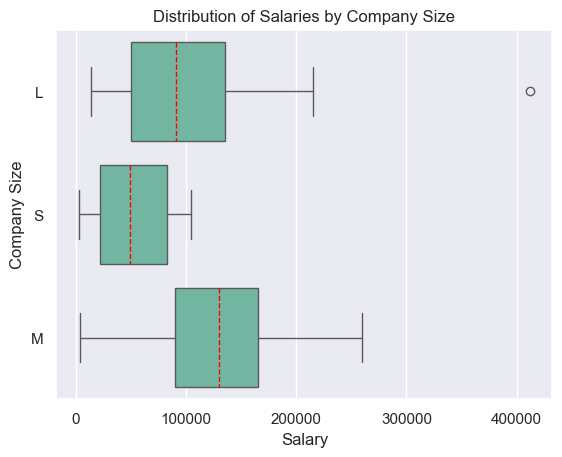

In [ ]:
ax = sns.boxplot(
    data[ds], x='salary_in_usd', y='company_size', orient='h',
    medianprops={"color": "red", "linestyle": '--'}
)
ax.set(xlabel='Salary', ylabel='Company Size')
plt.title('Distribution of Salaries by Company Size')
plt.show()

In [34]:
data_agg = data[ds].groupby('company_size')['salary_in_usd'].describe().round(2)
print('Distribution of Salaries by Company Size')
data_agg

Distribution of Salaries by Company Size


,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
L,45.0,103313.36,71815.18,13400.0,50000.0,90734.0,135000.0,412000.0
M,77.0,126380.75,56389.53,4000.0,90000.0,130000.0,165000.0,260000.0
S,21.0,51925.76,33216.29,2859.0,21669.0,49268.0,82500.0,105000.0


Data scientist salaries vary across companies of different sizes. To determine whether these differences are statistically significant, we'll conduct statistical tests in the next section.

### Data Scientist and Data Engineer Job Ratio by Company Size

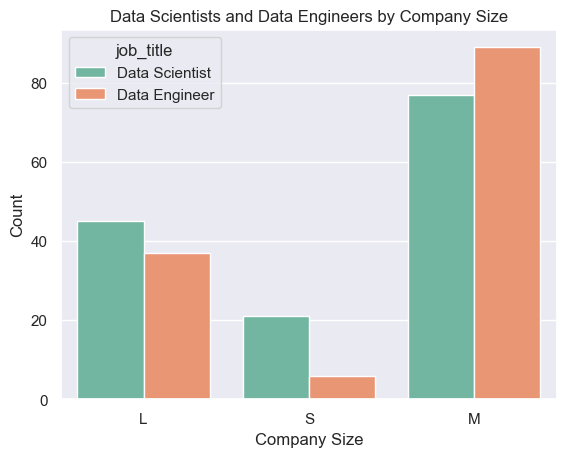

In [ ]:
ax = sns.countplot(data=data[ds|de], x=data[ds|de]['company_size'], hue='job_title')
ax.set(xlabel='Company Size', ylabel='Count')
plt.title('Data Scientists and Data Engineers by Company Size')
plt.show()

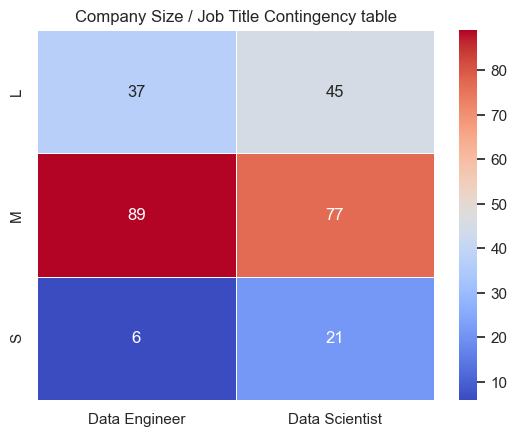

In [39]:
cross_tab = pd.crosstab(index=data[ds|de]['company_size'], columns=data[ds|de]['job_title'])
ax = sns.heatmap(cross_tab, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm")
ax.set(xlabel=None, ylabel=None)
plt.title('Company Size / Job Title Contingency table')
plt.show()

According to the data, small and large companies have more Data Scientist positions than Data Engineers. The opposite is true for medium-sized companies. To determine whether these differences are statistically significant, we will conduct statistical tests in the next section.

## Statistical data analysis

In [40]:
# function for making a decision on normality
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('The p-value is less than the specified significance level {:.2f}.'.format(alpha))
        print('The distribution is not normal.')
    else:
        print('The p-value is greater than the specified significance level {:.2f}.'.format(alpha))
        print('The distribution is normal.')

# function for making a decision on rejecting the null hypothesis
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('The p-value is less than the specified significance level {:.2f}.'.format(alpha))
        print('We reject the null hypothesis in favor of the alternative.')
    else:
        print('The p-value is greater than the specified level significance {:.2f}.'.format(alpha))
        print('We have no reason to reject the null hypothesis.')

### Is there annual salary growth for data scientists?

**Let's formulate the null and alternative hypotheses**

*Null hypothesis*: Salaries do not vary by year: 2020 ($μ_1$), 2021 ($μ_2$), 2022 ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Alternative hypothesis*: Salaries vary by year: 2020 ($μ_1$), 2021 ($μ_2$), 2022 ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Testing for Normality**

Using the Shapiro-Wilk test, we'll check whether the variable is normally distributed. Let's recall the hypotheses of the Shapiro-Wilk test:

Null hypothesis ($H_0$): the data are normally distributed.

Alternative hypothesis ($H_1$): the data are not normally distributed.

In [45]:
# salary values
salary_2020 = data[ds].loc[data[ds]['work_year']==2020, 'salary_in_usd']
salary_2021 = data[ds].loc[data[ds]['work_year']==2021, 'salary_in_usd']
salary_2022 = data[ds].loc[data[ds]['work_year']==2022, 'salary_in_usd']

# we conduct the Shapiro-Wilk test
print('Year 2020:')
result = stats.shapiro(salary_2020)
decision_normality(result[1])

print('\nYear 2021:')
result = stats.shapiro(salary_2021)
decision_normality(result[1])

print('\nYear 2022:')
result = stats.shapiro(salary_2022)
decision_normality(result[1])

Year 2020:
p-value = 0.000
The p-value is less than the specified significance level 0.05.
The distribution is not normal.

Year 2021:
p-value = 0.125
The p-value is greater than the specified significance level 0.05.
The distribution is normal.

Year 2022:
p-value = 0.327
The p-value is greater than the specified significance level 0.05.
The distribution is normal.


**Selecting a Suitable Statistical Test**

To select the appropriate test, we'll use the test selection algorithm. To do this, we'll answer the following questions:
* What type is the "Salary" feature? - Quantitative.
* How many groups are being compared? - Three.
* Are the groups dependent? - No.
* Is the feature normally distributed? - No.

To test our hypothesis, we can use the Kruskal-Wallis test.

**Conduct the Test**

In [46]:
# проводим тест
_, p = stats.kruskal(salary_2020, salary_2021, salary_2022)
decision_hypothesis(p)

p-value = 0.000
The p-value is less than the specified significance level 0.05.
We reject the null hypothesis in favor of the alternative.


**Conclusion**

There is reason to believe that salaries for data scientists are growing annually.

### How do Data Scientist and Data Engineer salaries compare in 2022?

**Let's formulate the null and alternative hypotheses**

*Null hypothesis* ($H_0$): The salary of a Data Engineer ($μ_1$) is statistically greater or equal to the salary of a Data Scientist ($μ_2$).

$$ H_0 : μ_1 >= μ_2$$

*Alternative hypothesis* ($H_1$): The salary of a Data Engineer ($μ_1$) is statistically less than the salary of a Data Scientist ($μ_2$).
$$ H_1 : μ_1 < μ_2$$

**Testing for Normality**

Using the Shapiro-Wilk test, we'll check whether the variable is normally distributed.

In [48]:
# salary values
salaries_de = data[year].loc[data[year]['job_title']=='Data Engineer', 'salary_in_usd']
salaries_ds = data[year].loc[data[year]['job_title']=='Data Scientist', 'salary_in_usd']

# running the Shapiro-Wilk test
print('For Data Engineers:')
result = stats.shapiro(salaries_de)
decision_normality(result[1])

print('\nFor Data Scientists:')
result = stats.shapiro(salaries_ds)
decision_normality(result[1])

For Data Engineers:
p-value = 0.010
The p-value is less than the specified significance level 0.05.
The distribution is not normal.

For Data Scientists:
p-value = 0.327
The p-value is greater than the specified significance level 0.05.
The distribution is normal.


**Selecting a Suitable Statistical Test**

To select the appropriate test, we'll use the test selection algorithm. To do this, we'll answer the following questions:
* What type of feature is "Salary"? - Quantitative.
* How many groups are being compared? - Two.
* Are the groups dependent? - No.
* Is the feature normally distributed? - No.

To test our hypothesis, we can use the Mann-Whitney U test.

**Conduct the Test**

In [52]:
# do a test
_, p = stats.mannwhitneyu(salaries_de, salaries_ds, alternative='less')
decision_hypothesis(p)

p-value = 0.077
The p-value is greater than the specified level significance 0.05.
We have no reason to reject the null hypothesis.


**Conclusion**

The salaries of Data Scientists and Data Engineers in 2022 are the same.

### How do data scientist salaries compare across companies of different sizes?

**Form the null and alternative hypotheses**

*Null hypothesis*: Data scientist salaries do not differ across companies of different sizes: small company ($μ_1$), medium company ($μ_2$), large company ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Alternative hypothesis*: Data scientist salaries differ across companies of different sizes: small company ($μ_1$), medium company ($μ_2$), large company ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Testing for Normality**

Using the Shapiro-Wilk test, we'll check whether the variable is normally distributed.

In [53]:
# salary values
small_companies = data[ds].loc[data[ds]['company_size']=='S', 'salary_in_usd']
medium_companies = data[ds].loc[data[ds]['company_size']=='M', 'salary_in_usd']
large_companies = data[ds].loc[data[ds]['company_size']=='L', 'salary_in_usd']

# running the Shapiro-Wilk test
print('For small companies:')
result = stats.shapiro(small_companies)
decision_normality(result[1])

print('\nFor medium companies:')
result = stats.shapiro(medium_companies)
decision_normality(result[1])

print('\nFor large companies:')
result = stats.shapiro(large_companies)
decision_normality(result[1])

For small companies:
p-value = 0.189
The p-value is greater than the specified significance level 0.05.
The distribution is normal.

For medium companies:
p-value = 0.639
The p-value is greater than the specified significance level 0.05.
The distribution is normal.

For large companies:
p-value = 0.000
The p-value is less than the specified significance level 0.05.
The distribution is not normal.


**Selecting a Suitable Statistical Test**

To select the appropriate test, we'll use the test selection algorithm. To do this, we'll answer the following questions:
* What type of feature is "Company Size"? - Quantitative.
* How many groups are being compared? - Three.
* Are the groups dependent? - No.
* Is the feature normally distributed? - No.

To test our hypothesis, we can use the Kruskal-Wallis test.

**Let's Conduct the Test**

In [54]:
# do a test
_, p = stats.kruskal(small_companies, medium_companies, large_companies)
decision_hypothesis(p)

p-value = 0.000
The p-value is less than the specified significance level 0.05.
We reject the null hypothesis in favor of the alternative.


**Conclusion**

There is reason to believe that there is a difference in salary levels across companies of different sizes.

### Is there a connection between the presence of Data Scientist and Data Engineer positions and company size?

**Let's formulate the null and alternative hypotheses**

*Null hypothesis*: There is no relationship between the presence of Data Scientist and Data Engineer positions and company size (these characteristics are independent).

*Alternative hypothesis*: There is a relationship between the presence of Data Scientist and Data Engineer positions and company size (these characteristics are dependent).

**Selecting a Suitable Statistical Test**

To select the appropriate test, we'll use the test selection algorithm. To do this, we'll answer the following questions:
* What type are the "Job Title" and "Company Size" features? — Categorical.
* Are the groups being tested for independence? — Yes.

To test our hypothesis, we can use the ${\chi}^2$ (chi-square) test.

**Conduct the Test**

In [55]:
# create a crosstab table
cross_table = pd.crosstab(data[ds|de]['job_title'], data[ds|de]['company_size'])

cross_table

company_size,L,M,S
job_title,,,
Data Engineer,37,89,6
Data Scientist,45,77,21


In [56]:
# run the test
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.008
The p-value is less than the specified significance level 0.05.
We reject the null hypothesis in favor of the alternative.


**Conclusion**

There is a statistically significant relationship between Job Title and Company Size.

## Final Research Results

* There is evidence to suggest that salaries for Data Scientists are growing annually.
* Data Scientist and Data Engineer salaries are similar in 2022.
* There is evidence to suggest that salaries for Data Scientists vary across companies of different sizes.
* There is a dependence between the availability of Data Scientist and Data Engineer positions and company size.